# 3. LightGBM как альтернативный бустинг

`distribution_of_responsoblities.txt`, Эксперимент 1: проверить, даёт ли LightGBM сопоставимое качество, и обосновать выбор CatBoost сравнением, а не предположением. Категории — нативно через pandas `category`.

Общий пайплайн, тайм-сплит 70/15/15 и метрики взяты из `preprocessing/preprocessing.py` и `team_modeling_protocol.txt` (через `scripts/p2_common.py`), чтобы результаты были сравнимы с другими участниками. Выбор моделей — по validation; test — только финальная оценка. Выборка — последние 30 000 строк по времени.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
_p2 = next((b for b in [_here, *_here.parents] if (b / "scripts" / "p2_common.py").exists()), _here)
sys.path.insert(0, str(_p2 / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import p2_common as C
from catboost import CatBoostRegressor, CatBoostClassifier, Pool

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (7, 3.4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
BLUE, ORANGE, GREEN, GREY = "#2b6cb0", "#dd6b20", "#2f855a", "#a0aec0"
print("pipeline OK | OUTPUT_DIR:", C.OUTPUT_DIR.name, "| MAX_ROWS:", C.MAX_ROWS)

pipeline OK | OUTPUT_DIR: outputs | MAX_ROWS: 30000


In [2]:
import lightgbm as lgb
from preprocessing.preprocessing import TargetTransform
p = C.get_pack((C.NEXT_TARGET,))[C.NEXT_TARGET]
def to_cat(df):
    df = df.copy()
    for c in p.cat_cols:
        df[c] = df[c].astype('category')
    return df
xtr, xva, xte = to_cat(p.x_train), to_cat(p.x_val), to_cat(p.x_test)
print('lightgbm', lgb.__version__)

lightgbm 4.6.0


## 3.1 Компактный случайный поиск

In [3]:
import random, time
grid = dict(objective=['regression_l1', 'quantile'], alpha=[0.40, 0.50],
            n_estimators=[600, 1000, 1400], learning_rate=[0.02, 0.03, 0.05],
            num_leaves=[31, 63], max_depth=[-1, 6, 8], feature_fraction=[0.8, 1.0],
            bagging_fraction=[0.8, 1.0], target_mode=['p995', 'log1p_p995'])
rng = random.Random(42); seen = set(); configs = []
while len(configs) < 14:
    cfg = {k: rng.choice(v) for k, v in grid.items()}
    if cfg['objective'] != 'quantile':
        cfg['alpha'] = 0.5
    key = tuple(sorted(cfg.items()))
    if key in seen:
        continue
    seen.add(key); configs.append(cfg)
rows = []
for i, cfg in enumerate(configs):
    tfm = TargetTransform(cfg['target_mode']).fit(p.y_train)
    params = dict(objective=cfg['objective'], n_estimators=cfg['n_estimators'],
                  learning_rate=cfg['learning_rate'], num_leaves=cfg['num_leaves'],
                  max_depth=cfg['max_depth'], feature_fraction=cfg['feature_fraction'],
                  bagging_fraction=cfg['bagging_fraction'], bagging_freq=1,
                  random_state=42, n_jobs=-1, verbosity=-1)
    if cfg['objective'] == 'quantile':
        params['alpha'] = cfg['alpha']
    model = lgb.LGBMRegressor(**params)
    t0 = time.time()
    model.fit(xtr, tfm.transform(p.y_train), eval_set=[(xva, tfm.transform(p.y_val))],
              callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)])
    fs = time.time() - t0
    ev = {s + '_mae': C.metric_pack(y, tfm.inverse(model.predict(X)))['mae']
          for s, X, y in [('val', xva, p.y_val), ('test', xte, p.y_test)]}
    rows.append(dict(model=f'lgb{i:02d}', objective=cfg['objective'], n_estimators=cfg['n_estimators'],
                     learning_rate=cfg['learning_rate'], num_leaves=cfg['num_leaves'],
                     val_mae=ev['val_mae'], test_mae=ev['test_mae'], fit_sec=round(fs, 1)))
lgbm = pd.DataFrame(rows).sort_values('val_mae').reset_index(drop=True)
display(lgbm.head(8))
import json
ref = C.OUTPUT_DIR / 'best_main_model.json'
cb = json.loads(ref.read_text()) if ref.exists() else None
if cb:
    print('CatBoost reference test_mae:', cb['test_mae'])

,model,objective,n_estimators,learning_rate,num_leaves,val_mae,test_mae,fit_sec
0,lgb12,regression_l1,1400,0.02,63,524.690719,431.248605,2.0
1,lgb09,regression_l1,1000,0.03,31,525.163723,430.061790,1.6
2,lgb13,regression_l1,1400,0.03,31,525.293554,430.260718,1.4
3,lgb03,regression_l1,1000,0.02,31,525.480109,430.518513,1.9
4,lgb00,regression_l1,1400,0.03,31,525.675189,431.274838,1.5
5,lgb10,quantile,600,0.03,31,525.687264,429.775407,1.7
6,lgb05,regression_l1,600,0.05,31,525.805828,430.425263,0.9
7,lgb08,quantile,1400,0.05,31,525.858403,431.089374,1.0


CatBoost reference test_mae: 428.4232019749596


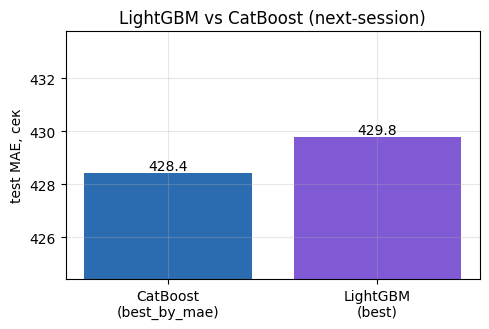

In [4]:
names = ['CatBoost\n(best_by_mae)', 'LightGBM\n(best)']
vals = [cb['test_mae'] if cb else np.nan, lgbm.test_mae.min()]
fig, ax = plt.subplots(figsize=(5, 3.4))
ax.bar(names, vals, color=[BLUE, '#805ad5'])
for i, v in enumerate(vals):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom')
ax.set_ylabel('test MAE, сек'); ax.set_ylim(min(vals) - 4, max(vals) + 4)
ax.set_title('LightGBM vs CatBoost (next-session)'); plt.tight_layout(); plt.show()

**Вывод.** Лучший LightGBM сопоставим, но чуть хуже CatBoost; CatBoost нативно работает с категориями и удобнее как единое семейство → остаёмся на CatBoost (по результату сравнения).